In [1]:
import subprocess
import pkg_resources
def check_and_update_yfinance():
    try:
        # Check the installed version of yfinance
        installed_version = pkg_resources.get_distribution("yfinance").version
        print(f"Currently installed yfinance version: {installed_version}")
    except pkg_resources.DistributionNotFound:
        print("yfinance is not installed.")
        installed_version = None
    # Update or install the latest version
    print("Checking for the latest version of yfinance...")
    try:
        subprocess.check_call(["pip", "install", "--upgrade", "yfinance"])
        print("yfinance has been updated to the latest version.")
    except subprocess.CalledProcessError as e:
        print("An error occurred while updating yfinance:", e)
if __name__ == "__main__":
    check_and_update_yfinance()

#Kabir

Currently installed yfinance version: 0.2.50
Checking for the latest version of yfinance...
yfinance has been updated to the latest version.



[notice] A new release of pip available: 22.2.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


The above block of code is used to make sure that we have the latest yfinance version so that there are no errors.

In [2]:
from IPython.display import display, Math, Latex

import pandas as pd
import numpy as np
import numpy_financial as npf
import yfinance as yf
import matplotlib.pyplot as plt
import random
from datetime import datetime
import itertools # Library for creating and using "Iterators" on multiple python types.
 # Tra

In [3]:
investment_size = 1000000
min_stocks = 12
max_stocks = 24
flat_fee = 3.95
fee_per_share = 0.001
ticker_file = pd.read_csv('Tickers_Example.csv', header=None)
ticker_file.rename(columns={0: 'name'}, inplace=True)

#Kabir

These variables are defined for the calculations and to create our portfolio. We use flat fee and fee per share because the assignment states to use the lower price for the flat fee or fee per share. Investment size will be manipulated as we move through the ticker list to reflect purchases.

In [4]:
def clean_data(tickers):
    filtered_stocks = pd.DataFrame()
    start_date = "2023-10-01"
    end_date = "2024-09-30"
    for ticker in tickers['name']:
        try:
            stock = yf.Ticker(ticker)
            info = stock.fast_info
            if info['currency'] not in ["USD", "CAD"]: # Enusring stock is listed, traded in CAD or USD
                continue
    
            hist = stock.history(start=start_date, end=end_date, interval="1d")
            hist['Month'] = hist.index.to_period('M')
            monthly_data = hist.groupby('Month').filter(lambda x: len(x) >= 18)

            avg_monthly_volume = monthly_data.groupby('Month')['Volume'].mean().mean()
            if avg_monthly_volume >= 100000:
                filtered_stocks = pd.concat([filtered_stocks, pd.DataFrame({"Ticker": [ticker]})])
                
        except Exception as e:
            continue
    
    return filtered_stocks.reset_index(drop=True)

#Tra

In [5]:
ticker_file = clean_data(ticker_file)

/var/folders/0n/r4s34nf565330b8vj1m60v3m0000gp/T/ipykernel_94067/3727452313.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
/var/folders/0n/r4s34nf565330b8vj1m60v3m0000gp/T/ipykernel_94067/3727452313.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
/var/folders/0n/r4s34nf565330b8vj1m60v3m0000gp/T/ipykernel_94067/3727452313.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
/var/folders/0n/r4s34nf565330b8vj1m60v3m0000gp/T/ipykernel_94067/3727452313.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist['Month'] = hist.index.to_period('M')
$AGN: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
/var/folde

In [6]:
def getBeta(cur_ticker):
    SP_ticker = '^GSPC'

    cur_stock = yf.Ticker(cur_ticker)
    SP_index = yf.Ticker(SP_ticker)

    # Will edit these later
    start_date = '2023-11-14'
    end_date = '2024-11-21'

    cur_stock_hist = cur_stock.history(start=start_date, end=end_date)
    SP_index_hist = SP_index.history(start=start_date, end=end_date)

    prices = pd.DataFrame()
    prices[cur_ticker] = pd.DataFrame(cur_stock_hist['Close'])
    prices['S&P Index'] = SP_index_hist['Close']

    daily_returns = prices.pct_change(fill_method=None).dropna()
    daily_returns.drop(index=daily_returns.index[0], inplace=True)

    SP_var = daily_returns['S&P Index'].var()
    SP_beta = daily_returns.cov() / SP_var
    currency = cur_stock.fast_info.currency
    todays_price = cur_stock.fast_info.last_price

    if currency == 'USD':
        cadusd = yf.Ticker('CADUSD=x')
        exchange = cadusd.fast_info.last_price
        todays_price = todays_price / exchange

    return SP_beta.iat[0,1], todays_price

#Kabir

This portion of the code calculates the **beta** of a stock (its sensitivity to market movements) relative to the S&P 500 index and retrieves its current price. It uses historical price data to compute daily returns for both the stock and the index, determines the stock's variance relative to the index, and calculates beta. If the stock's currency is in USD, it converts the price to CAD using the latest exchange rate. The function ultimately returns the beta value and the adjusted stock price, providing insights into the stock's volatility and current valuation.

SP_ticker: Represents the ticker for the S&P 500 index (^GSPC).
cur_stock: Fetches stock data for the given ticker symbol using the yfinance library.
SP_index: Fetches stock data for the S&P 500 index.

Using these variables, we retrieve histroical data about the given stock and the historical data from the S&P 500.

We then create dataframe display the closing prices of both and calculate the daily returns.
Using this data we are able to calculate the beta value which is covariance of the stock's returns with the S&P 500 index, divided by the S&P 500 variance. 

Beta is useful for portfolio creation because:
1. Measures Market Sensitivity
Beta indicates how a stock's price reacts to market movements:
Beta > 1: The stock is more volatile than the market. If the market moves 1%, the stock might move more than 1% in the same direction.
Beta < 1: The stock is less volatile than the market, moving less dramatically than the market.
Beta = 1: The stock moves in sync with the market.
Beta < 0: The stock moves inversely to the market.

2. Evaluates Systematic Risk
Beta captures systematic risk, which is the risk inherent to the entire market. Unlike unsystematic risk (company-specific), systematic risk cannot be eliminated through diversification.



In [7]:
# Gets average of daily growth
def getGrowth(cur_ticker):
    # Fetch data for current stock
    cur_stock = yf.Ticker(cur_ticker)
    start_date = '2023-11-14'
    end_date = '2024-11-21'
    cur_stock_hist = cur_stock.history(start=start_date, end=end_date)

    prices = pd.DataFrame()
    prices[cur_ticker] = cur_stock_hist['Close']
    
    daily_returns = prices.pct_change(fill_method=None).dropna()
    SP_growth = daily_returns.mean()
    
    return SP_growth[cur_ticker] * 100

#Tra

In [8]:
def getVolatility(cur_ticker):
    start_date = '2023-11-14'
    end_date = '2024-11-21'
    stock_data = yf.Ticker(cur_ticker).history(start=start_date, end=end_date)
    stock_data['Daily Return'] = stock_data['Close'].pct_change(fill_method=None).dropna()
    
    volatility = stock_data['Daily Return'].std()
    return volatility

#Kabir

The getVolatility function calculates the volatility of a stock over a specified time period. Volatility measures the degree of variation in the stock's daily returns and is often used as an indicator of risk.

The function will retrieve the percentage change everyday and calculate the volatility through the standard deviation function.
Volatility is a critical metric in stock analysis and portfolio management because it reflects the degree of risk and uncertainty associated with a stock's price movements. Including volatility in stock-related functions is beneficial for several reasons:

1. Measures Risk
Volatility represents the fluctuations in a stock's price over a given period. A highly volatile stock experiences larger price swings, indicating higher risk.
Low volatility suggests stable price movements, which might be attractive to risk-averse investors.

2. Complements Other Metrics
While beta measures a stock's volatility relative to the market, volatility measures absolute risk, irrespective of market movements.
Combining volatility with other metrics like beta and expected return provides a more comprehensive view of a stock’s risk-reward profile.

3. Aids in Portfolio Management
Investors can adjust their portfolio composition based on the volatility of individual stocks:
High-volatility stocks are suitable for aggressive investors seeking higher potential returns but willing to tolerate risk.
Low-volatility stocks appeal to conservative investors prioritizing stability.

In [9]:

# Initialize the lists
stock_data = []
beta_data = []
volatility_data = []
growth_data = []

# Iterate through the tickers and gather data
for i in range(len(ticker_file)):
    cur_ticker = ticker_file['Ticker'].iloc[i]
    cur_stock = yf.Ticker(cur_ticker)
    start_date = '2023-11-14'
    end_date = '2024-11-21'
    cur_stock_hist = cur_stock.history(start=start_date, end=end_date)['Close']

    # Getting important statistics per stock
    beta, price = getBeta(cur_ticker)
    beta_data.append({"name": cur_ticker, "beta": beta})
    growth = getGrowth(cur_ticker)
    growth_data.append({"name": cur_ticker, "growth": growth})
    volatility = getVolatility(cur_ticker)
    volatility_data.append({"name": cur_ticker, "volatility": volatility})

    # Store combined stock details
    stock_details = {
        "name": cur_ticker,
        "beta": beta,
        "growth": growth,
        "volatility": volatility,
        "price": price,
        "price_history": cur_stock_hist
    }
    stock_data.append(stock_details)

# Sort the data by each criterion
sorted_betas = sorted(beta_data, key=lambda d: d['beta'], reverse=True)
sorted_growth = sorted(growth_data, key=lambda d: d['growth'], reverse=True)
sorted_volatility = sorted(volatility_data, key=lambda d: d['volatility'], reverse=True)

# Combine the lists into one iterable
lists = [sorted_betas, sorted_growth, sorted_volatility]
weights = [0.4, 0.3, 0.3]  # Corresponding weights for beta, growth, and volatility

# Step 1: Calculate weighted average index position for each stock
index_map = {}
for weight, lst in zip(weights, lists):
    for index, stock in enumerate(lst):
        name = stock["name"]
        if name not in index_map:
            index_map[name] = 0
        # Add the weighted index to the total
        index_map[name] += index * weight

# Step 2: Convert index_map to a list of dictionaries for sorting
weighted_positions = [
    {"name": name, "weighted_index": total_index}
    for name, total_index in index_map.items()
]

# Step 3: Sort stocks by their weighted index
sorted_by_weighted = sorted(weighted_positions, key=lambda x: x["weighted_index"])

# Final result: A list of stocks sorted by the weighted average of their index positions
result = [{"name": stock["name"], "weighted_index": stock["weighted_index"]} for stock in sorted_by_weighted]

#Tra

In [10]:
best_stocks = []
for i in range(24):
    best_stocks += [result[i]["name"]]

In [11]:
filtered_stocks = []
for stock in best_stocks:
    for stock_stats in stock_data:
        if (stock == stock_stats["name"]):
            filtered_stocks += [stock_stats]

filtered_stocks

[{'name': 'SHOP.TO',
  'beta': np.float64(1.6907375909160385),
  'growth': np.float64(0.23905400676089805),
  'volatility': np.float64(0.03207653792469171),
  'price': 148.80999755859375,
  'price_history': Date
  2023-11-14 00:00:00-05:00     89.769997
  2023-11-15 00:00:00-05:00     92.849998
  2023-11-16 00:00:00-05:00     92.690002
  2023-11-17 00:00:00-05:00     93.870003
  2023-11-20 00:00:00-05:00     95.449997
                                  ...    
  2024-11-14 00:00:00-05:00    153.429993
  2024-11-15 00:00:00-05:00    152.869995
  2024-11-18 00:00:00-05:00    148.490005
  2024-11-19 00:00:00-05:00    145.990005
  2024-11-20 00:00:00-05:00    145.339996
  Name: Close, Length: 257, dtype: float64},
 {'name': 'QCOM',
  'beta': np.float64(2.0099073549570035),
  'growth': np.float64(0.1112659652062063),
  'volatility': np.float64(0.023769059107499674),
  'price': 217.30666706436725,
  'price_history': Date
  2023-11-14 00:00:00-05:00    124.756920
  2023-11-15 00:00:00-05:00   

In [12]:
def generate_numbers(n, min_value, max_value, total_sum):
    total_lower = n * min_value
    total_upper = n * max_value
    if total_sum < total_lower or total_sum > total_upper:
        raise ValueError("Cannot generate numbers with the given constraints.")

    # Calculate the adjusted sum we need to distribute
    remaining_sum = total_sum - total_lower
    adjusted_upper_bounds = [max_value - min_value] * n

    # Generate initial random values
    u = [random.random() for _ in range(n)]
    adjusted_weights = [u_i * adjusted_upper_bounds[i] for i, u_i in enumerate(u)]
    adjusted_weights_sum = np.sum(adjusted_weights)

    # Scale the weights to match the remaining sum
    scaling_factor = remaining_sum / adjusted_weights_sum
    adjusted_weights = [w_i * scaling_factor for w_i in adjusted_weights]

    # Compute the final values
    x = [min_value + w_i for w_i in adjusted_weights]

    return x

#Kabir

generate_numbers, creates random weight percentages within a defined range (e.g., 0% to 15%) that sum up to a specific target value. It is used to assign weights to stocks in a portfolio while adhering to certain constraints. It ensures that the total_sum is achievable given the constraints:
total_lower: The minimum possible sum if all weights are set to min_value.
total_upper: The maximum possible sum if all weights are set to max_value.
Raises an error if the total_sum is outside the feasible range.
Using these constraints it adjusts the remaining sum and bound to continue generating within the required bounds.
Using random.randint, random values are generated and then scaled to fit within the given bounds.

By assigning random weights, we can generate multiple portfolios, enabling us to explore a wide range of potential combinations. This approach is similar to the Monte Carlo method, which relies on random sampling to solve optimization problems. By generating diverse portfolio configurations, we can identify the best-performing portfolio based on predefined metrics. The stock that scores highest according to these metrics will receive the largest weight, ensuring the portfolio aligns with our investment strategy and objectives.



In [13]:
TSX_index = yf.Ticker('XIU.TO')
SP_index = yf.Ticker('^GSPC')
cadusd = yf.Ticker('CADUSD=x')

# Will edit these later
start_date = '2023-11-14'
end_date = '2024-11-21'

TSX_index_hist = TSX_index.history(start=start_date, end=end_date)['Close']
TSX_index_hist.index = TSX_index_hist.index.strftime('%Y-%m-%d')
SP_index_hist = SP_index.history(start=start_date, end=end_date)['Close']
SP_index_hist.index = SP_index_hist.index.strftime('%Y-%m-%d')
cadusd_history = cadusd.history(start=start_date, end=end_date)['Close']
cadusd_history.index = cadusd_history.index.strftime('%Y-%m-%d')

SP_index_hist = SP_index_hist / cadusd_history

benchmark = (TSX_index_hist + SP_index_hist) / 2

for stock in filtered_stocks:
    stock["price_history"].index = stock["price_history"].index.strftime('%Y-%m-%d')


#Tra

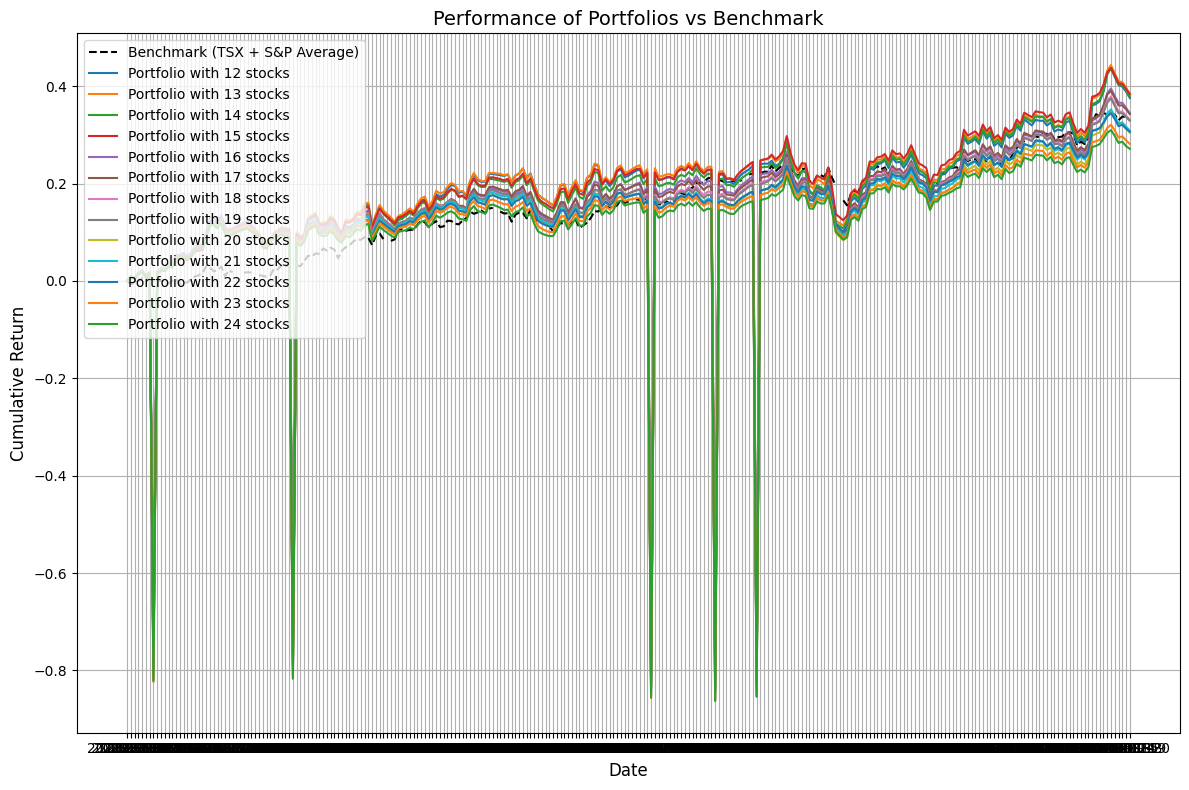

In [14]:
def make_portfolios(stock_details, budget):
    strongest_portfolios = {}
    back_testing_portfolios = {}
    benchmark = (TSX_index_hist + SP_index_hist) / 2

    for n in range(12, 25):  # Loop through the number of stocks in the portfolio
        best_portfolio = None
        best_portfolio_backtesting = None
        best_invest_coeff = float('-inf')

        for j in range(1000):  # Create 100 portfolios with different weights for the current number of stocks
            stocks = stock_details[:n]
            max_weight = 15
            min_weight = 100 / (2 * n)
            generate = True
            
            # Generate valid weights for the portfolio
            while generate:
                weights = generate_numbers(n, min_weight, max_weight, 100)
                if all(min_weight <= weight <= max_weight for weight in weights):
                    generate = False
            
            weights.sort(reverse=True)

            current_portfolio = pd.DataFrame()
            fees_spent = 0
            total_spent = 0

            # Create a dataframe for daily portfolio value calculation
            portfolio_values = pd.DataFrame()
            
            for i in range(len(stocks)):
                stock_weight = weights[i]
                money_allocated = budget * (stock_weight / 100)  # Allocate money based on weight
                
                # Deduct the flat fee initially to estimate spendable money
                flat_fee = 3.95
                money_for_stock = money_allocated - flat_fee
                
                if money_for_stock < 0:
                    shares = 0
                    transaction_fees = 0
                else:
                    shares = money_for_stock / stocks[i]["price"]  # Calculate shares
                    variable_fee = shares * 0.001
                    transaction_fees = min(flat_fee, variable_fee)  # Use the smaller fee
                    
                    # Adjust the number of shares based on fees
                    money_for_shares = money_allocated - transaction_fees
                    shares = money_for_shares / stocks[i]["price"]
                    actual_spent = shares * stocks[i]["price"] + transaction_fees
                    
                    # Update total spent and fees
                    total_spent += actual_spent
                    fees_spent += transaction_fees
                
                # Append stock details to the current portfolio
                new_row = {
                    'Name': stocks[i]["name"],
                    'weight': weights[i],
                    'shares': shares,
                    'price': stocks[i]["price"],
                    'transaction fees': transaction_fees,
                    'spent': actual_spent,
                    'weighted beta': stocks[i]['beta'] * (weights[i] / 100)
                }
                current_portfolio = pd.concat([current_portfolio, pd.DataFrame(new_row, index=[0])], ignore_index=True)
                
                # Add stock's daily value (shares * daily price) to the portfolio_values dataframe
                stock_values = stocks[i]["price_history"] * shares
                portfolio_values[stocks[i]["name"]] = stock_values
            
            # Compute portfolio total value
            portfolio_values['Portfolio'] = portfolio_values.sum(axis=1)
            
            # Calculate portfolio return from first day to final day
            portfolio_return = (
                portfolio_values['Portfolio'].iloc[-1] - portfolio_values['Portfolio'].iloc[0]
            ) / portfolio_values['Portfolio'].iloc[0]
            
            # Calculate portfolio daily returns and Sharpe ratio
            daily_returns = portfolio_values['Portfolio'].pct_change().dropna()
            avg_daily_return = daily_returns.mean()
            std_daily_return = daily_returns.std()
            sharpe_ratio = avg_daily_return / std_daily_return if std_daily_return > 0 else 0
            
            # Calculate portfolio beta
            portfolio_beta = current_portfolio['weighted beta'].sum()
            
            # Compute investment coefficient
            investment_coefficient = 0.3 * portfolio_beta + 0.5 * portfolio_return + 0.2 * sharpe_ratio
            
            # Check if this portfolio is the best for this number of stocks
            if investment_coefficient > best_invest_coeff:
                best_invest_coeff = investment_coefficient
                best_portfolio = current_portfolio.copy()
                best_portfolio_backtesting = portfolio_values.copy()
                best_portfolio["Portfolio Return"] = portfolio_return
                best_portfolio["Sharpe Ratio"] = sharpe_ratio
                best_portfolio["Investment Coefficient"] = investment_coefficient

        # Store the best portfolio for this number of stocks
        strongest_portfolios[n] = best_portfolio
        back_testing_portfolios[n] = best_portfolio_backtesting
        
        # Add a summary row to the best portfolio
        final_row = {
            'Name': 'Total',
            'weight': best_portfolio['weight'].sum(),
            'shares': best_portfolio['shares'].sum(),
            'price': best_portfolio['price'].sum(),
            'transaction fees': best_portfolio['transaction fees'].sum(),
            'spent': best_portfolio['spent'].sum(),
            'weighted beta': portfolio_beta,
            'Portfolio Return': portfolio_return,
            'Sharpe Ratio': sharpe_ratio,
            'Investment Coefficient': best_invest_coeff
        }
        strongest_portfolios[n] = pd.concat([best_portfolio, pd.DataFrame(final_row, index=[0])], ignore_index=True)

    # Graphing the performance of the strongest portfolios and the benchmark
    plt.figure(figsize=(12, 8))

    # Plot benchmark performance
    benchmark_cum_return = (benchmark / benchmark.iloc[0]) - 1
    plt.plot(benchmark.index, benchmark_cum_return, label="Benchmark (TSX + S&P Average)", color="black", linestyle="--")

    # Plot the strongest portfolios
    for n, portfolio_values in back_testing_portfolios.items():
        portfolio_cum_return = (portfolio_values['Portfolio'] / portfolio_values['Portfolio'].iloc[0]) - 1
        plt.plot(portfolio_cum_return.index, portfolio_cum_return, label=f"Portfolio with {n} stocks")

    # Customize plot
    plt.title("Performance of Portfolios vs Benchmark", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return", fontsize=12)
    plt.legend(fontsize=10, loc="upper left")
    plt.grid(True)
    plt.tight_layout()

    plt.show()


    return strongest_portfolios

best_portfolios = make_portfolios(filtered_stocks, investment_size)

The make_portfolios function generates and evaluates stock portfolios to identify the strongest ones based on metrics such as portfolio return, Sharpe ratio, and beta. It creates random portfolios with 12 to 24 stocks by assigning weights within specified limits and allocating a given budget accordingly. For each portfolio, the function calculates transaction fees, daily values, cumulative returns, and risk-adjusted metrics while benchmarking performance against the average of the TSX and S&P 500 indices. The best-performing portfolio for each stock count is selected based on an investment coefficient that balances return, risk, and market sensitivity. Finally, the function plots portfolio performance against the benchmark and returns the strongest portfolios for further analysis.

Generating multiple portfolios is valuable because it allows investors to explore a wide range of potential combinations, ensuring the identification of the most optimal one based on key metrics like return, risk, and Sharpe ratio. By simulating diverse allocation strategies, it provides a more robust understanding of how different portfolios perform under varying market conditions, similar to the Monte Carlo method. This approach also helps mitigate risk through diversification and ensures alignment with budget, stock weight constraints, and investment goals. Ultimately, it improves decision-making by enabling a data-driven evaluation of the best-performing portfolios.

In [15]:
best_port = pd.DataFrame()
best_investment_coeff = 0
for i in range(12, 25):
    cur_portfolio = best_portfolios[i]
    cur_investment_coeff = cur_portfolio['Investment Coefficient'].iloc[0]

    if cur_investment_coeff > best_investment_coeff:
        best_investment_coeff = cur_investment_coeff
        best_port = cur_portfolio

display(best_port)

,Name,weight,shares,price,transaction fees,spent,weighted beta,Portfolio Return,Sharpe Ratio,Investment Coefficient
0,SHOP.TO,14.972018,1006.109666,148.809998,1.006090,1.497202e+05,0.253138,0.375690,0.106943,0.617042
1,QCOM,14.108664,649.248342,217.306667,0.649233,1.410866e+05,0.283571,0.375690,0.106943,0.617042
2,PYPL,12.773396,1077.333246,118.563943,1.077309,1.277340e+05,0.137825,0.375690,0.106943,0.617042
3,CAT,11.368562,208.757724,544.580599,0.208751,1.136856e+05,0.140857,0.375690,0.106943,0.617042
4,AMZN,9.053621,326.488927,277.301530,0.326476,9.053621e+04,0.137691,0.375690,0.106943,0.617042
5,C,7.678022,796.629249,96.380377,0.796597,7.678022e+04,0.083509,0.375690,0.106943,0.617042
6,TXN,5.851350,211.201257,277.049909,0.211188,5.851350e+04,0.082885,0.375690,0.106943,0.617042
7,AXP,5.738190,140.104441,409.564201,0.140095,5.738190e+04,0.057387,0.375690,0.106943,0.617042
8,USB,4.781466,665.608574,71.835000,0.665563,4.781466e+04,0.047578,0.375690,0.106943,0.617042
9,LLY,4.725326,45.077737,1048.260678,0.045074,4.725326e+04,0.039734,0.375690,0.106943,0.617042


In [17]:
# Create the "Portfolio_Final" DataFrame
Portfolio_Final = pd.DataFrame()
Portfolio_Final['Ticker'] = best_portfolios[12]['Name']  # Adjust the index to the desired portfolio
Portfolio_Final['Price'] = best_portfolios[12]['price']
Portfolio_Final['Currency'] = 'CAD'  # Assuming all values are in CAD
Portfolio_Final['Shares'] = best_portfolios[12]['shares']
Portfolio_Final['Value'] = best_portfolios[12]['spent']
Portfolio_Final['Weight'] = (
    (Portfolio_Final['Value'] / Portfolio_Final['Value'].sum()) * 100
)

# Ensure the total value and weights add up correctly
"Total weights do not sum to 100%"

# Print "Portfolio_Final" DataFrame to screen
print("\nPortfolio_Final:")
print(Portfolio_Final)

# Create the "Stocks_Final" DataFrame
Stocks_Final = Portfolio_Final[['Ticker', 'Shares']]

# Save "Stocks_Final" to CSV
group_number = "XX"  # Replace XX with your group number
Stocks_Final.to_csv(f"Stocks_Group_{group_number}.csv", index=False)

print(f"\nDataFrame 'Stocks_Final' saved as Stocks_Group_{group_number}.csv")



Portfolio_Final:
     Ticker        Price Currency        Shares         Value     Weight
0   SHOP.TO   148.809998      CAD   1006.109666  1.497202e+05   7.486009
1      QCOM   217.306667      CAD    649.248342  1.410866e+05   7.054332
2      PYPL   118.563943      CAD   1077.333246  1.277340e+05   6.386698
3       CAT   544.580599      CAD    208.757724  1.136856e+05   5.684281
4      AMZN   277.301530      CAD    326.488927  9.053621e+04   4.526810
5         C    96.380377      CAD    796.629249  7.678022e+04   3.839011
6       TXN   277.049909      CAD    211.201257  5.851350e+04   2.925675
7       AXP   409.564201      CAD    140.104441  5.738190e+04   2.869095
8       USB    71.835000      CAD    665.608574  4.781466e+04   2.390733
9       LLY  1048.260678      CAD     45.077737  4.725326e+04   2.362663
10      BAC    64.943182      CAD    726.942104  4.721066e+04   2.360533
11    BB.TO     3.260000      CAD  12969.091881  4.228319e+04   2.114159
12    Total  3277.856084      CAD